In [1]:
import networkx as nx
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.optim import SGD
import random

Для простоты валидации созданных моделей оставил лекционный граф для рассмотрения: чтобы визуально можно было оценить, корректно ли работают модели.

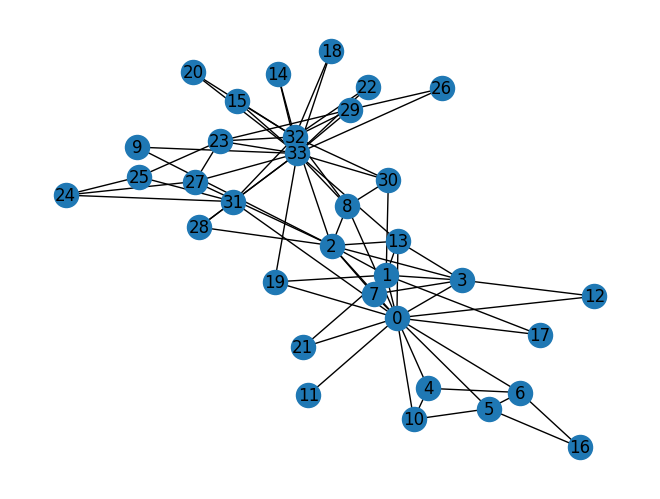

In [2]:
G = nx.karate_club_graph()
# Visualize the graph
nx.draw(G, with_labels = True)

Реализую алгоритм случайного блуждания и буду хранить для каждой вершины массив вероятностей встретить каждую из вершин графа при блуждании.

**DeepWalk**

In [22]:
def DeepWalk(G, num_of_paths = 10, len_of_path = 10, t = 5):
  num_of_nodes = G.number_of_nodes()
  emb = torch.nn.Embedding(num_embeddings = num_of_nodes, embedding_dim = num_of_nodes)
  positive_nodes = [] #массив вершин, которые встретились при обходе
  negative_nodes = [] #массив из указанного количества вершин, которые не встретились
  #в цикле по числу вершин графа
  for i in range(num_of_nodes):
    temp_emb = np.zeros(num_of_nodes) #текущая частота посещения соседних вершин
    temp_pos_nodes = [] #текущее список вершин, которые встретились при обходе
    temp_neg_nodes = np.zeros(t) #массив из указанного количества вершин, которые не встретились
    #в цикле по количеству блуждающих путей
    for j in range(num_of_paths):
      temp_node = i #текущая вершина
      nodes_in_path = set() #множество посещенных вершин
      nodes_in_path.add(temp_node)
      #в цикле по числу шагов в пути
      for k in range(len_of_path):
        #собираю список доступных соседей для перехода на каждом шаге
        avail_neighb = []
        for neighb in G.neighbors(temp_node):
          avail_neighb.append(neighb)
        #выбираю случайно следующую вершину в пути
        next_node = random.choice(avail_neighb)
        #добавляю в список обхода и меняю текущую вершину в блуждании
        nodes_in_path.add(next_node)
        temp_node = next_node
      #изменяю число посещения каждой из вершин для очередной вершины
      #и записываю в множество посещенных вершин
      for nodes in nodes_in_path:
        temp_emb[nodes] += 1
        temp_pos_nodes.append(nodes)
    #заполняю список не посещенных вершин
    neg_samples = []
    #определяю все не посещенные вершины
    for j in range(len(temp_emb)):
      if temp_emb[j] == 0 :
        neg_samples.append(j)
    #случайно отбираю t непосещенных вершин
    for j in range(t):
      temp_neg_nodes[j] = random.choice(neg_samples)

    #записываю вероятность встретить каждую из вершин при обходе
    emb.weight.data[i] = torch.Tensor(temp_emb / num_of_paths)
    #сохраняю списки посещенных и непосещенных вершин при обходе
    positive_nodes.append(temp_pos_nodes)
    negative_nodes.append(temp_neg_nodes)

  return emb, positive_nodes, np.array(negative_nodes)

Получаем всю матрицу эмбеддингов, а также списки позитивных и негативных вершин.

In [23]:
emb, pos_nodes, neg_nodes = DeepWalk(G)

Снизим размерность пространства эмбеддингов и визуализируем.

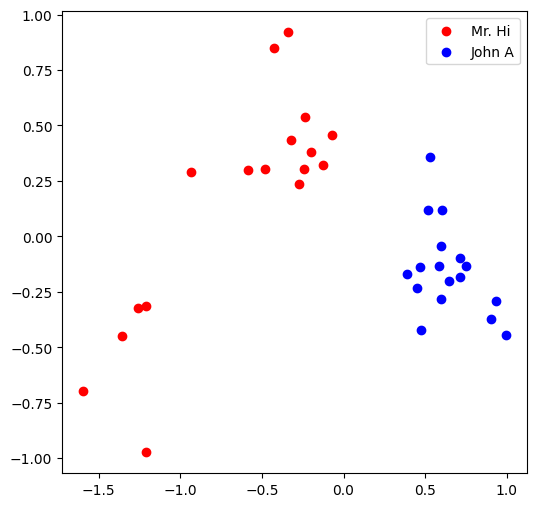

In [24]:
def visualize_emb(emb):
  X = emb.weight.data.numpy()
  pca = PCA(n_components=2)
  components = pca.fit_transform(X)
  plt.figure(figsize=(6, 6))
  club1_x = []
  club1_y = []
  club2_x = []
  club2_y = []
  for node in G.nodes(data=True):
    if node[1]['club'] == 'Mr. Hi':
      club1_x.append(components[node[0]][0])
      club1_y.append(components[node[0]][1])
    else:
      club2_x.append(components[node[0]][0])
      club2_y.append(components[node[0]][1])
  plt.scatter(club1_x, club1_y, color="red", label="Mr. Hi")
  plt.scatter(club2_x, club2_y, color="blue", label="John A")
  plt.legend()
  plt.show()

# Visualize the initial random embeddding
visualize_emb(emb)

Можно отметить, что изначально уже заметна определенная разделимость классов.

**loss**

In [25]:
def Loss(emb, pos_nodes, neg_nodes):
  V = len(emb.weight.data)
  L = 0
  for u in range(V):
    Nr_u = pos_nodes[u]
    for v in Nr_u:
      ZuT_Zv = torch.sum(torch.mul(emb.weight[u], emb.weight[int(v)]), axis = 0)
      L += torch.log(torch.sigmoid(ZuT_Zv))
      k = neg_nodes[u]
    for i in k:
      ZuT_ZTi = torch.sum(torch.mul(emb.weight[u], emb.weight[int(i)]), axis = 0)
      L += torch.log(torch.sigmoid(-ZuT_ZTi))
  #изначально неверно интерпретировал формулу с лекцией
  return -L

Реализую функцию train

In [26]:
def train(emb, pos_nodes, neg_nodes):
  epochs = 100
  learning_rate = 0.01
  optimizer = SGD(emb.parameters(), lr = learning_rate, momentum = 0.9)
  for i in range(epochs):
    optimizer.zero_grad()
    loss = Loss(emb, pos_nodes, neg_nodes)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
      if i % 25 == 0:
        print(loss)
        visualize_emb(emb)

tensor(542.5253, grad_fn=<NegBackward0>)


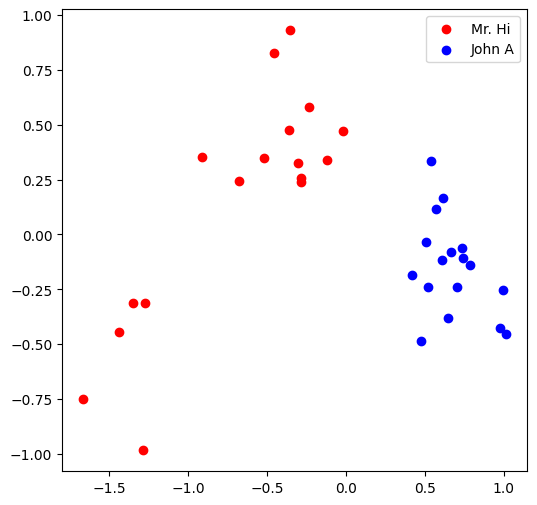

tensor(193.4861, grad_fn=<NegBackward0>)


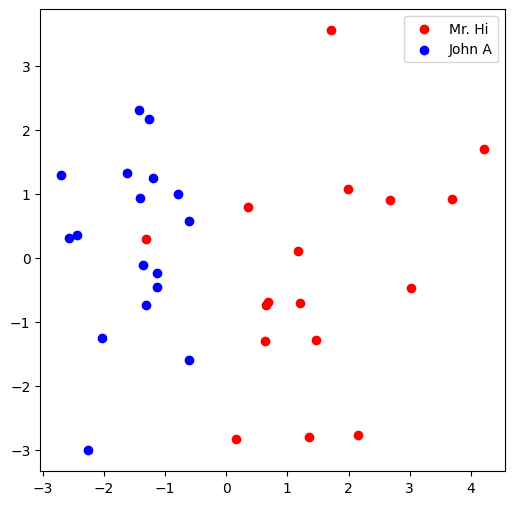

tensor(179.5720, grad_fn=<NegBackward0>)


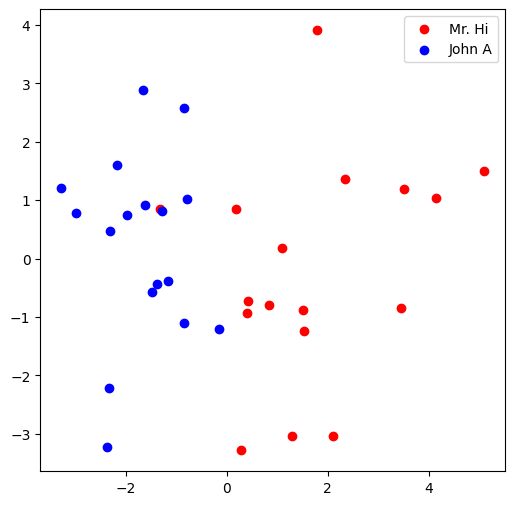

tensor(178.5787, grad_fn=<NegBackward0>)


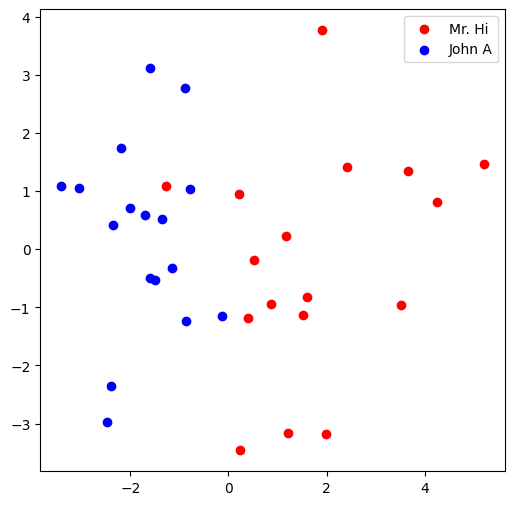

In [27]:
train(emb, pos_nodes, neg_nodes)

При использовании большего числа эпох картинки начинают ухудшаться, и классы визуально перестают быть разделимы + loss перестает уменьшаться -- это может свидетельствовать о том, что все признаки модель уже вытянула, и в дальнейшем может только переобучаться.

**Node2Vec**

Алгоритм Node2Vec отличается от DeepWalk тем, что учитывает вероятность возвращаемости к вершинам при случайном блуждании, поэтому изменю только функцию DeepWalk и попробую обучить модель на том же графе.

Отличие реализуется в выборе очередного шага при случайном блуждании и зависят от параметров p и q: p отвечает за вероятность вернуться к вершине, из которой пришли, а q - определяет вероятность перехода к вершинам, которые не являются соседями вершины, из которой перешли. С помощью варьирования p и q можно регулировать, насколько будут влиять локальные и глобальные зависимости вершин в графе на итоговую классификацию.

In [28]:
def Node2Vec(G, num_of_paths = 10, len_of_path = 10, t = 5, p = 1, q = 0.5):
  num_of_nodes = G.number_of_nodes()
  emb = torch.nn.Embedding(num_embeddings = num_of_nodes, embedding_dim = num_of_nodes)
  positive_nodes = [] #массив вершин, которые встретились при обходе
  negative_nodes = [] #массив из указанного количества вершин, которые не встретились
  #в цикле по числу вершин графа
  for i in range(num_of_nodes):
    temp_emb = np.zeros(num_of_nodes) #текущая частота посещения соседних вершин
    temp_pos_nodes = [] #текущее список вершин, которые встретились при обходе
    temp_neg_nodes = np.zeros(t) #массив из указанного количества вершин, которые не встретились
    #в цикле по количеству блуждающих путей
    pred_node = i #запоминаю предыдущую вершину
    avail_neighb_pred_node = set() #запоминаю множество соседей для предыдущей вершины
    for j in range(num_of_paths):
      temp_node = i #текущая вершина
      nodes_in_path = set() #множество посещенных вершин
      nodes_in_path.add(temp_node)


      #в этой части кода вношу изменения при определении следующего шага в блуждании
      #в цикле по числу шагов в пути
      for k in range(len_of_path):
        #собираю список доступных соседей для перехода на каждом шаге
        avail_neighb = []
        for neighb in G.neighbors(temp_node):
          #в зависимости от p и q заполняю массив соседей
          #учитываю их вероятности в числе повторений в массиве
          if neighb == pred_node:
            for f in range(int(1/p)):
              avail_neighb.append(neighb)
          elif neighb in avail_neighb_pred_node:
            avail_neighb.append(neighb)
          else:
            for f in range(int(1/q)):
              avail_neighb.append(neighb)
        #выбираю случайно следующую вершину в пути
        next_node = random.choice(avail_neighb)
        #добавляю в список обхода и меняю текущую и предыдущую вершинуы в блуждании
        pred_node = temp_node
        nodes_in_path.add(next_node)
        temp_node = next_node
        #обновляю множество соседей предыдущей вершины
        for f in range(len(avail_neighb)):
          avail_neighb_pred_node.add(avail_neighb[f])

      #изменяю число посещения каждой из вершин для очередной вершины
      #и записываю в множество посещенных вершин
      for nodes in nodes_in_path:
        temp_emb[nodes] += 1
        temp_pos_nodes.append(nodes)
    #заполняю список не посещенных вершин
    neg_samples = []
    #определяю все не посещенные вершины
    for j in range(len(temp_emb)):
      if temp_emb[j] == 0 :
        neg_samples.append(j)
    #случайно отбираю t непосещенных вершин
    for j in range(t):
      temp_neg_nodes[j] = random.choice(neg_samples)

    #записываю вероятность встретить каждую из вершин при обходе
    emb.weight.data[i] = torch.Tensor(temp_emb / num_of_paths)
    #сохраняю списки посещенных и непосещенных вершин при обходе
    positive_nodes.append(temp_pos_nodes)
    negative_nodes.append(temp_neg_nodes)

  return emb, positive_nodes, np.array(negative_nodes)

In [29]:
emb2, pos_nodes2, neg_nodes2 = Node2Vec(G)

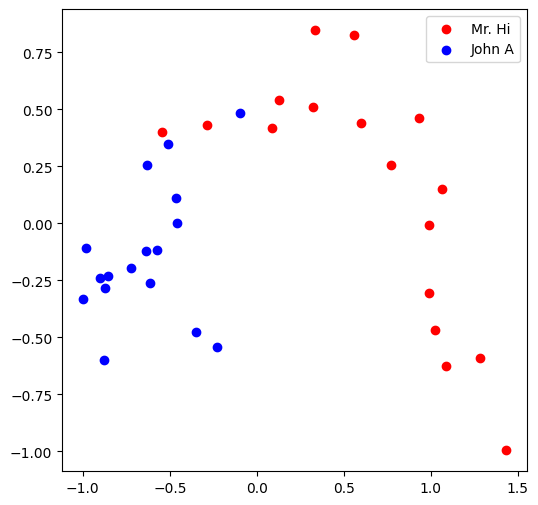

In [31]:
def visualize_emb(emb):
  X = emb.weight.data.numpy()
  pca = PCA(n_components=2)
  components = pca.fit_transform(X)
  plt.figure(figsize=(6, 6))
  club1_x = []
  club1_y = []
  club2_x = []
  club2_y = []
  for node in G.nodes(data=True):
    if node[1]['club'] == 'Mr. Hi':
      club1_x.append(components[node[0]][0])
      club1_y.append(components[node[0]][1])
    else:
      club2_x.append(components[node[0]][0])
      club2_y.append(components[node[0]][1])
  plt.scatter(club1_x, club1_y, color="red", label="Mr. Hi")
  plt.scatter(club2_x, club2_y, color="blue", label="John A")
  plt.legend()
  plt.show()

# Visualize the initial random embeddding
visualize_emb(emb2)

При первичной инициализации визуально объекты различаются чуть хуже, однако, по ошибке - значение несколько лучше (513 против 542).

tensor(513.0643, grad_fn=<NegBackward0>)


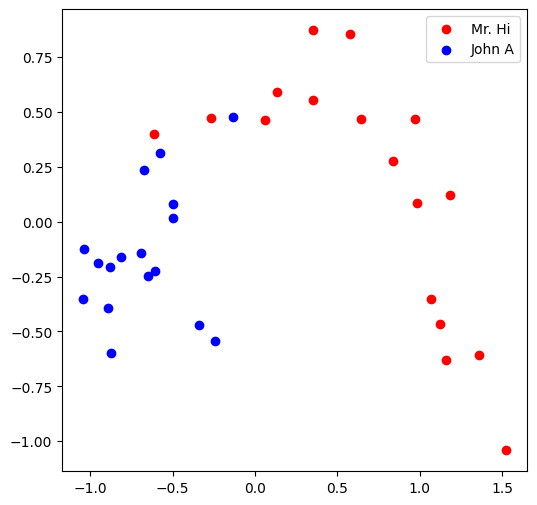

tensor(184.4913, grad_fn=<NegBackward0>)


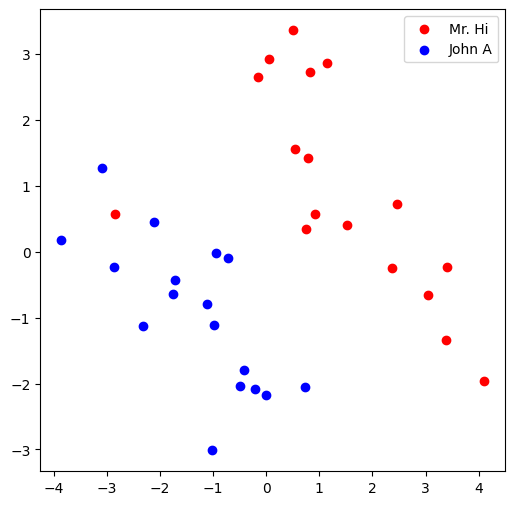

tensor(170.7499, grad_fn=<NegBackward0>)


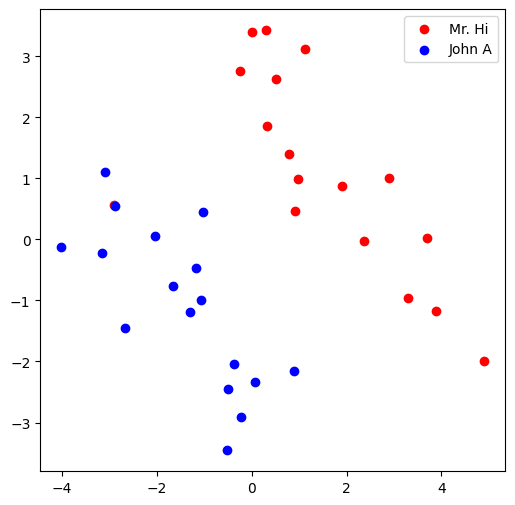

tensor(169.8254, grad_fn=<NegBackward0>)


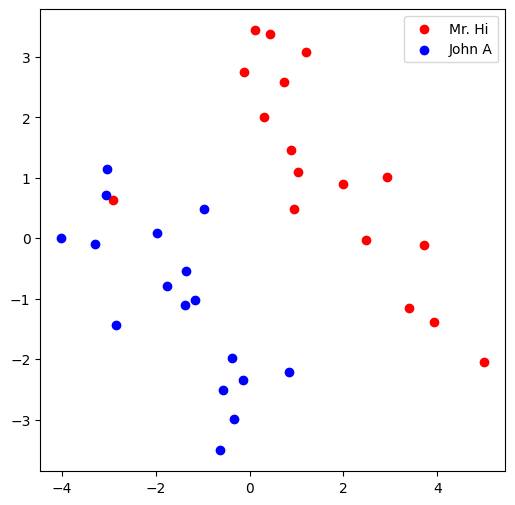

In [32]:
train(emb2, pos_nodes2, neg_nodes2)

Заметна явная разделимость классов (более четкая, чем при DeepWalk) + значение ошибки меньше (169 против 178) - если не брать в расчет одну из точек - возможно, проявившую себя как выброс.

Получается, что можно сделать вывод о том, что Node2Vec показал себя лучше при бинарной классификации вершин.